<a href="https://colab.research.google.com/github/NethmiKaveeshaE23174/Statistical-Learning-e23174/blob/main/Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "git+https://github.com/NethmiKaveeshaE23174/Statistical-Learning-e23174.git"

  Cloning https://github.com/NethmiKaveeshaE23174/Statistical-Learning-e23174.git to /tmp/pip-req-build-8rmbmzci
  Running command git clone --filter=blob:none --quiet https://github.com/NethmiKaveeshaE23174/Statistical-Learning-e23174.git /tmp/pip-req-build-8rmbmzci
  Resolved https://github.com/NethmiKaveeshaE23174/Statistical-Learning-e23174.git to commit 8da9d0dd9403683782f44db87a622c69dfd051e7
  Preparing metadata (setup.py) ... done


In [22]:
# Manual setup to fix the 'dara inspector' folder name issue
import os, sys

repo_name = 'Statistical-Learning-e23106'
incorrect_package_path = os.path.join(repo_name, 'dara inspector')
correct_package_path = os.path.join(repo_name, 'data_inspector')

if not os.path.exists(repo_name):
    print(f"Cloning {repo_name} from GitHub...")
    !git clone https://github.com/e23106-eng/Statistical-Learning-e23106.git
else:
    print(f"{repo_name} already exists. Pulling latest updates...")
    !cd {repo_name} && git pull

# Check if the problematic folder exists and rename it
if os.path.exists(incorrect_package_path):
    print(f"Found incorrect package folder: '{incorrect_package_path}'. Renaming to '{correct_package_path}'...")
    os.rename(incorrect_package_path, correct_package_path)
    print("Rename successful.")
elif not os.path.exists(correct_package_path):
    print(f"Warning: Neither '{incorrect_package_path}' nor '{correct_package_path}' found. Package might be missing.")

# Add the cloned repository's base directory to sys.path
# This allows direct import of 'data_inspector' after renaming
sys.path.insert(0, os.path.abspath(repo_name))

print("Setup complete. You should now be able to import 'data_inspector'.")

Cloning Statistical-Learning-e23106 from GitHub...
Cloning into 'Statistical-Learning-e23106'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 24 (delta 5), reused 12 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 662.27 KiB | 8.28 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Setup complete. You should now be able to import 'data_inspector'.


In [23]:
from data_inspector import DataInspector, PlottingMethods

In [24]:
import pandas as pd
from data_inspector import DataInspector
inspector = DataInspector()

# Initialize and Upload
inspector.upload_data()
# Alternatively use
#inspector.df=pd.read_csv('xxxx.csv')

# inspector.upload_data()
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
inspector.df = pd.read_csv(url)

Saving titanic_sample.csv to titanic_sample (3).csv
✅ Successfully loaded 'titanic_sample (3).csv' (20 rows, 10 columns).


In [27]:
# Introduce some synthetic garbage strings to showcase sanitisation
inspector.df.loc[0, 'Age']    = '?'
inspector.df.loc[1, 'Cabin']  = 'NULL'
inspector.df.loc[2, 'Fare']   = 'n/a'

# Re-run sanitisation manually (upload_data() does this automatically)
import numpy as np
_GARBAGE = {'?','n/a','na','null','none','nan',' ','','--','N/A','NULL','None','NaN','NA'}
inspector.df.replace(_GARBAGE, np.nan, inplace=True)
# inspector.auto_convert_types() # This method is not available in the current DataInspector object

print(f'Dataset loaded: {inspector.df.shape[0]:,} rows × {inspector.df.shape[1]} columns')
inspector.df.head()

Dataset loaded: 891 rows × 12 columns


/tmp/ipykernel_28504/1143009735.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '?' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[0, 'Age']    = '?'
/tmp/ipykernel_28504/1143009735.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'n/a' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inspector.df.loc[2, 'Fare']   = 'n/a'
/tmp/ipykernel_28504/1143009735.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inspector.df.replace(_GARBAGE, np.nan, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,NaN,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,NaN,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# 4-A  Full summary: shape, first 20 rows, numeric & categorical stats
inspector.data_summary()

 STRUCTURAL SUMMARY: 891 Rows | 12 Columns
 Numeric Features (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
 Categorical Features (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,NaN,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,NaN,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# 4-B  Column-level detail: dtype, nulls, unique counts
import pandas as pd

df = inspector.df

dtypes = df.dtypes.rename('Data Type')
null_counts = df.isnull().sum().rename('Null Count')
unique_counts = df.nunique().rename('Unique Count')

column_details_df = pd.concat([dtypes, null_counts, unique_counts], axis=1)
print(column_details_df)

            Data Type  Null Count  Unique Count
PassengerId     int64           0           891
Survived        int64           0             2
Pclass          int64           0             3
Name           object           0           891
Sex            object           0             2
Age           float64         178            88
SibSp           int64           0             7
Parch           int64           0             7
Ticket         object           0           681
Fare          float64           1           248
Cabin          object         688           146
Embarked       object           2             3


In [33]:
# 4-C  Categorical value-count tables

df = inspector.df

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- Value Counts for '{col}' ---")
    print(df[col].value_counts())
    print("\n")


--- Value Counts for 'Name' ---
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64



--- Value Counts for 'Sex' ---
Sex
male      577
female    314
Name: count, dtype: int64



--- Value Counts for 'Ticket' ---
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463 

/tmp/ipykernel_28504/1085684933.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')


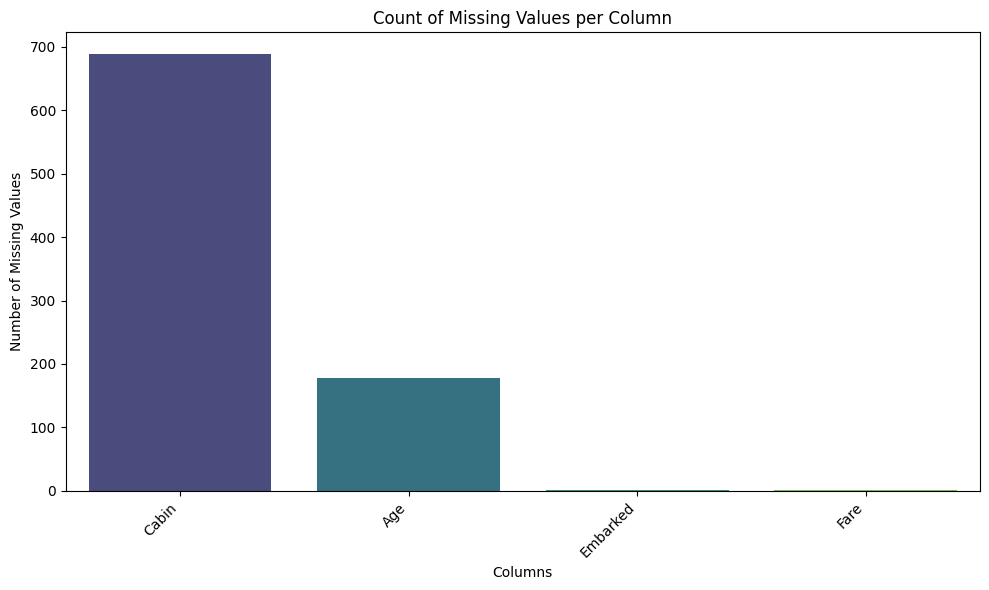

In [35]:
# 4-D  Missing-value bar chart
import matplotlib.pyplot as plt
import seaborn as sns

df = inspector.df

# Calculate missing values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis')
    plt.title('Count of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the DataFrame.")

In [37]:
# 4-E  Drop high-null columns that aren't useful for modelling
#      (interactive: leave blank and it will prompt; or pass a string directly)
columns_to_drop = ['Cabin', 'Ticket', 'Name']
inspector.df = inspector.df.drop(columns=columns_to_drop)
print(f"Columns dropped: {columns_to_drop}. New DataFrame shape: {inspector.df.shape}")

Columns dropped: ['Cabin', 'Ticket', 'Name']. New DataFrame shape: (891, 9)


In [40]:
import numpy as np
# 4-F  Impute remaining missing values
#      Age  → median  (numeric, skewed)
#      Fare → median (numeric)
#      Embarked → mode  (categorical)

# Impute 'Age' with its median using direct assignment
inspector.df['Age'] = inspector.df['Age'].fillna(inspector.df['Age'].median())

# Impute 'Fare' with its median using direct assignment
inspector.df['Fare'] = inspector.df['Fare'].fillna(inspector.df['Fare'].median())

# Impute 'Embarked' with its mode (most frequent value) using direct assignment
# .mode()[0] is used because mode() can return multiple values if there's a tie
inspector.df['Embarked'] = inspector.df['Embarked'].fillna(inspector.df['Embarked'].mode()[0])

# Display missing data after imputation
# Since `data_inspector.show_missing_data()` might also be problematic or not visually useful
# I'll replace it with a direct check using pandas
print('Missing values after imputation:')
print(inspector.df.isnull().sum()[inspector.df.isnull().sum() > 0])


Missing values after imputation:
Series([], dtype: int64)


In [42]:
# 4-G  Remove duplicate rows
initial_rows = inspector.df.shape[0]
inspector.df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - inspector.df.shape[0]
print(f"Removed {duplicates_removed} duplicate rows.")
print(f"New DataFrame shape: {inspector.df.shape}")


Removed 0 duplicate rows.
New DataFrame shape: (891, 9)


In [44]:
# 4-H  Outlier detection & removal via IQR

import numpy as np

def remove_iqr_outliers(df, columns):
    initial_rows = df.shape[0]
    df_cleaned = df.copy()

    for col in columns:
        if pd.api.types.is_numeric_dtype(df_cleaned[col]):
            Q1 = df_cleaned[col].quantile(0.25)
            Q3 = df_cleaned[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Keep rows where the column value is within the bounds
            df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
        else:
            print(f"Skipping non-numeric column '{col}' for outlier detection.")

    rows_removed = initial_rows - df_cleaned.shape[0]
    print(f"Removed {rows_removed} rows containing outliers.")
    print(f"New DataFrame shape: {df_cleaned.shape}")
    return df_cleaned

# Apply the outlier removal function to the inspector's DataFrame
columns_for_outliers = ['Age', 'Fare', 'SibSp', 'Parch']
inspector.df = remove_iqr_outliers(inspector.df, columns_for_outliers)


Removed 314 rows containing outliers.
New DataFrame shape: (577, 9)


Univariate Visualisations

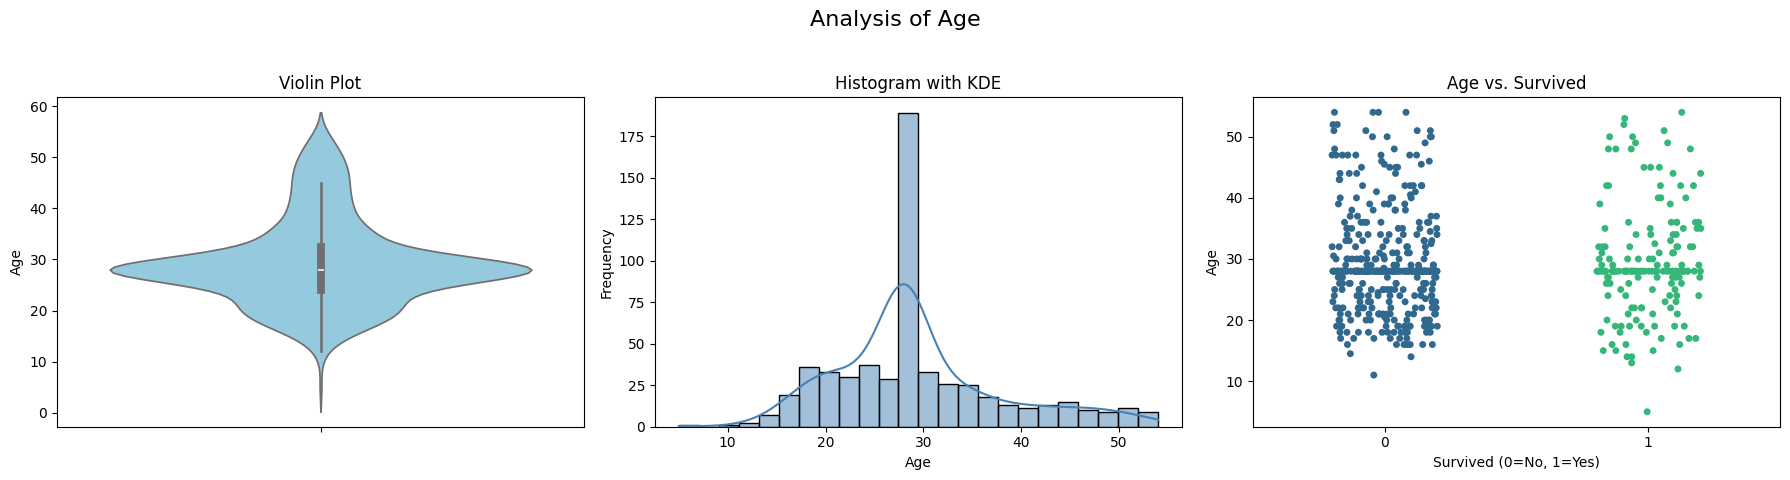

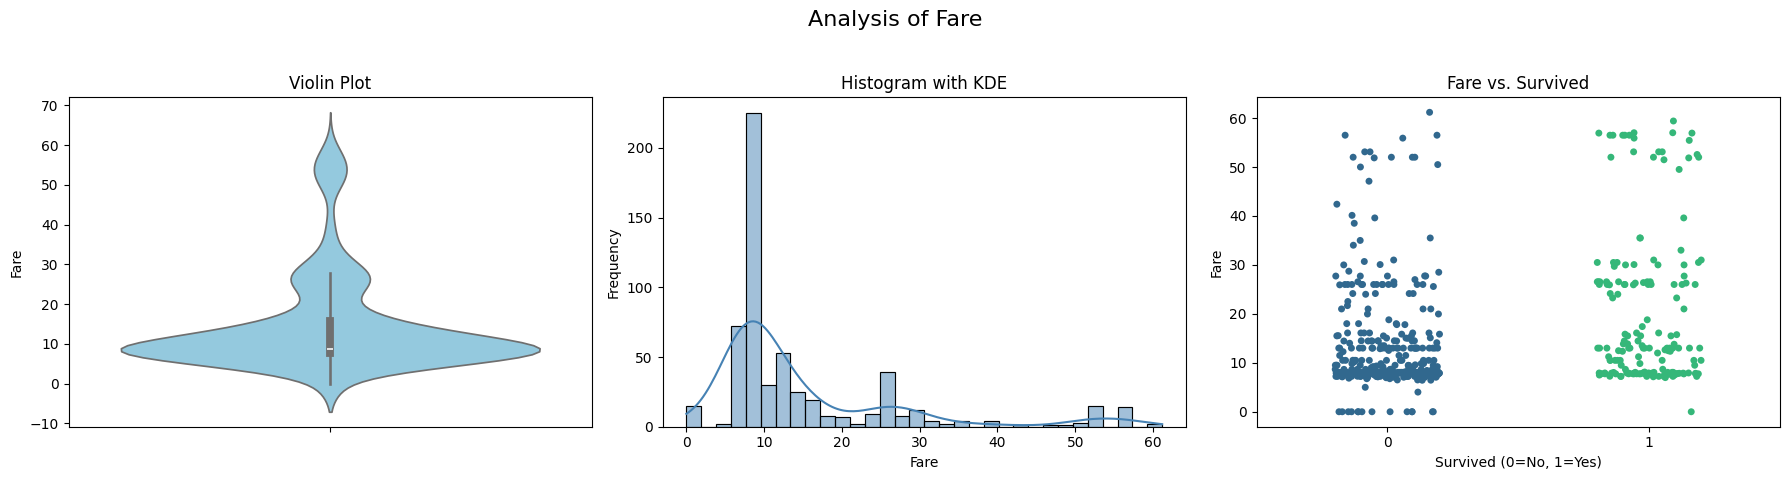

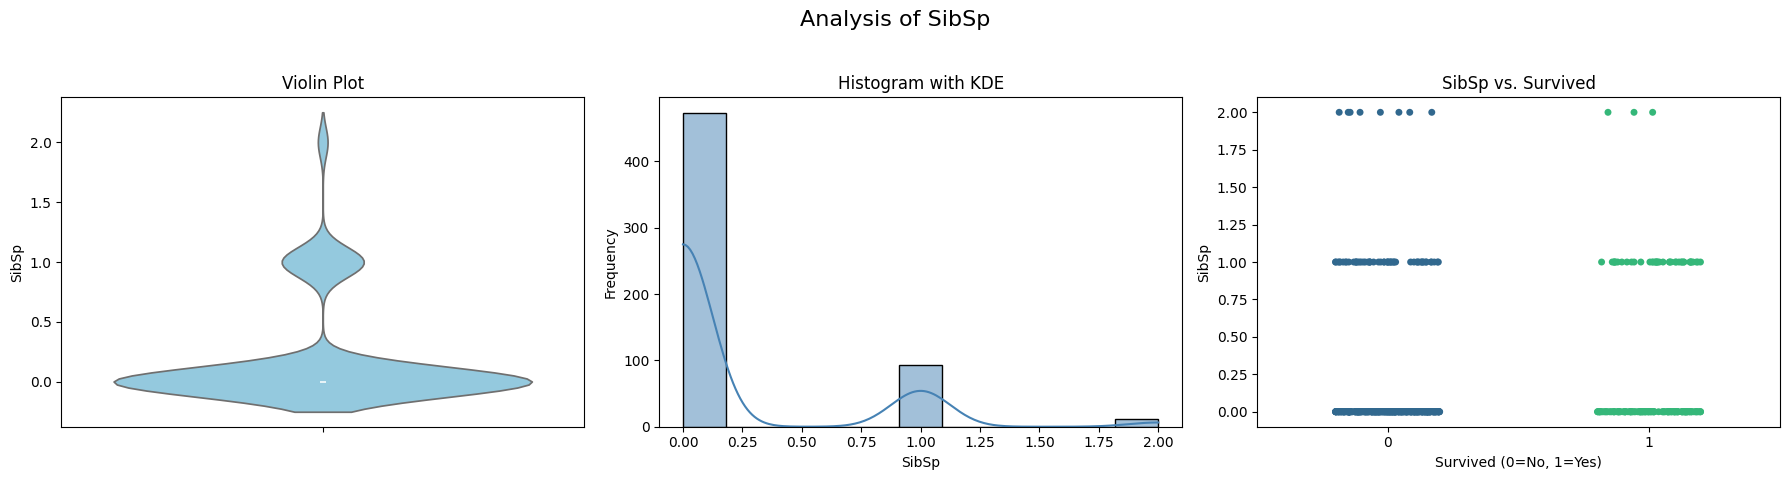

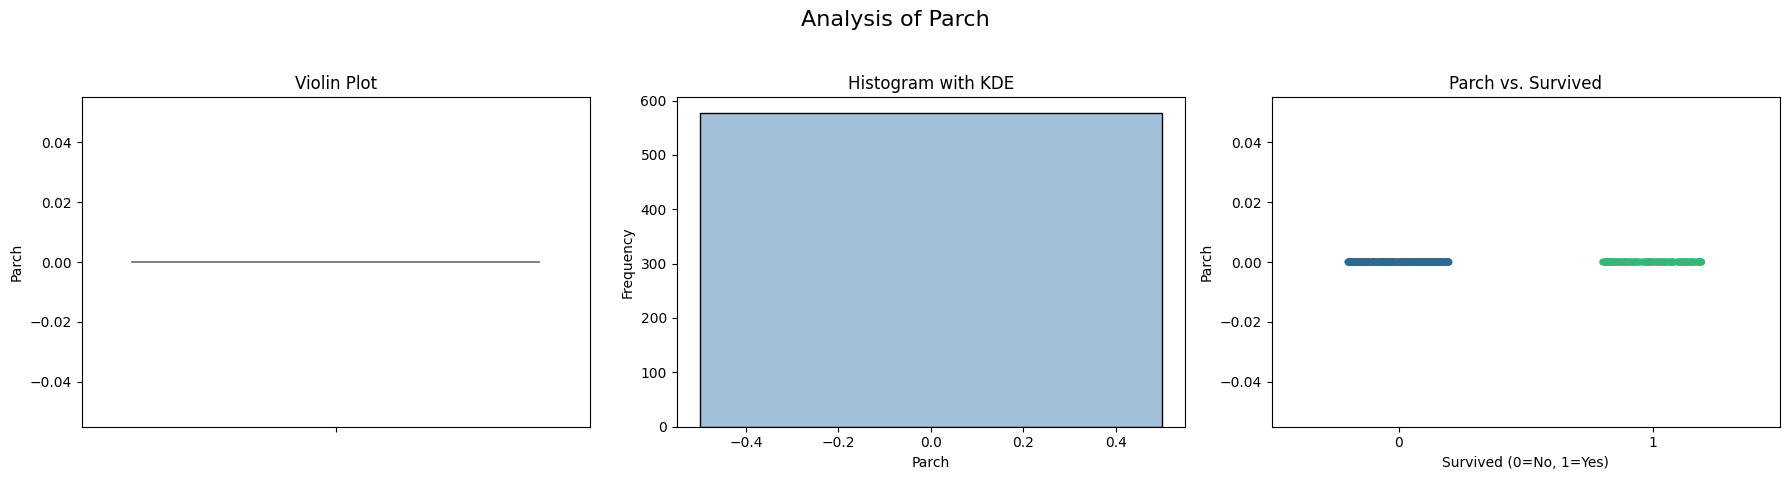

In [48]:
# 5-A  3-panel numeric subplots: Violin | Strip | Histogram

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

columns_to_plot = ['Age', 'Fare', 'SibSp', 'Parch']

for col in columns_to_plot:
    if col in inspector.df.columns and pd.api.types.is_numeric_dtype(inspector.df[col]):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Analysis of {col}', fontsize=16)

        # Violin Plot (using 'color' instead of 'palette' to avoid FutureWarning for single plot)
        sns.violinplot(y=inspector.df[col], ax=axes[0], color='skyblue') # Changed palette to color
        axes[0].set_title('Violin Plot')
        axes[0].set_ylabel(col)

        # Histogram
        sns.histplot(x=inspector.df[col], kde=True, ax=axes[1], color='steelblue') # Changed color for variety
        axes[1].set_title('Histogram with KDE')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Frequency')

        # Strip Plot (assigning x variable to hue and setting legend=False to address FutureWarning)
        if 'Survived' in inspector.df.columns:
            sns.stripplot(x=inspector.df['Survived'], y=inspector.df[col], jitter=0.2, ax=axes[2],
                          hue=inspector.df['Survived'], palette='viridis', legend=False) # Added hue and legend=False
            axes[2].set_title(f'{col} vs. Survived')
            axes[2].set_xlabel('Survived (0=No, 1=Yes)')
            axes[2].set_ylabel(col)
        else:
            # Fallback if 'Survived' column is not available or not suitable
            sns.scatterplot(x=inspector.df.index, y=inspector.df[col], ax=axes[2], color='red', alpha=0.6)
            axes[2].set_title(f'Scatter Plot of {col}')
            axes[2].set_xlabel('Index')
            axes[2].set_ylabel(col)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f"Column '{col}' not found or is not numeric in the DataFrame, skipping.")


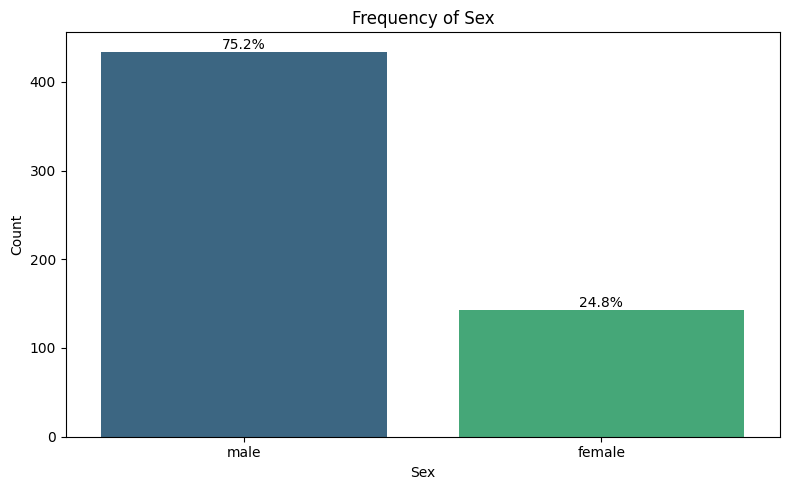

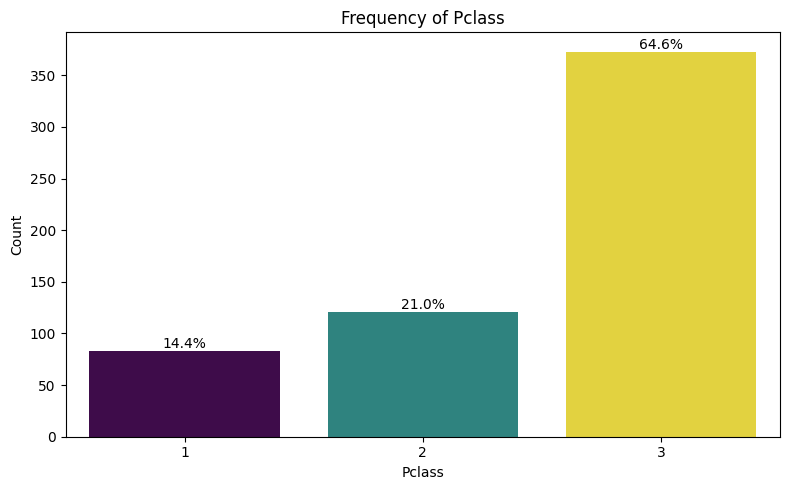

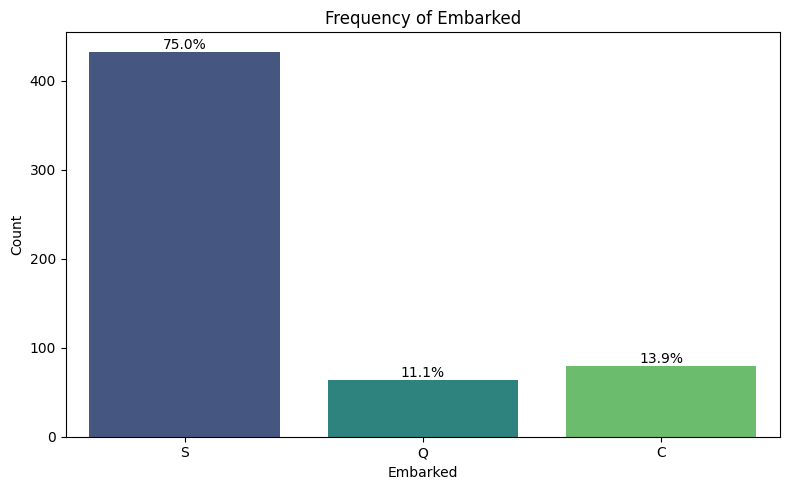

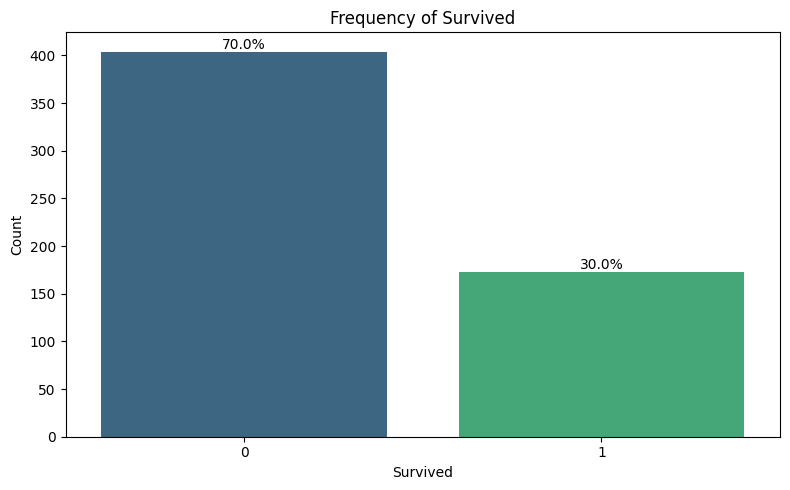

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 5-B  Categorical frequency bar charts with % labels
categorical_cols_to_plot = ['Sex', 'Pclass', 'Embarked', 'Survived']

for col in categorical_cols_to_plot:
    if col in inspector.df.columns and not pd.api.types.is_numeric_dtype(inspector.df[col]):
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x=col, data=inspector.df, palette='viridis', hue=col, legend=False) # Added hue=col and legend=False
        plt.title(f'Frequency of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

        # Add percentage labels on top of bars
        total = len(inspector.df[col])
        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

        plt.tight_layout()
        plt.show()
    elif col in inspector.df.columns and pd.api.types.is_numeric_dtype(inspector.df[col]) and inspector.df[col].nunique() < 10: # Assuming 'Survived' is numeric but categorical-like
        plt.figure(figsize=(8, 5))
        ax = sns.countplot(x=col, data=inspector.df, palette='viridis', hue=col, legend=False) # Added hue=col and legend=False
        plt.title(f'Frequency of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')

        total = len(inspector.df[col])
        for p in ax.patches:
            percentage = '{:.1f}%'.format(100 * p.get_height()/total)
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, color='black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found or is not suitable for categorical plotting.")

 Bivariate Relationships

In [51]:
# Num–Num: Scatter with OLS trendline
inspector.plot_relationship('Age', 'Fare')

In [52]:
# Cat–Num: Box plot with individual points
inspector.plot_relationship('Pclass', 'Fare')

In [53]:
# Cat–Num: Survival by Sex
inspector.plot_relationship('Sex', 'Survived')

In [54]:
# Cat–Cat: Grouped bar — Embarked × Pclass
inspector.plot_relationship('Embarked', 'Pclass')

Association Heatmaps

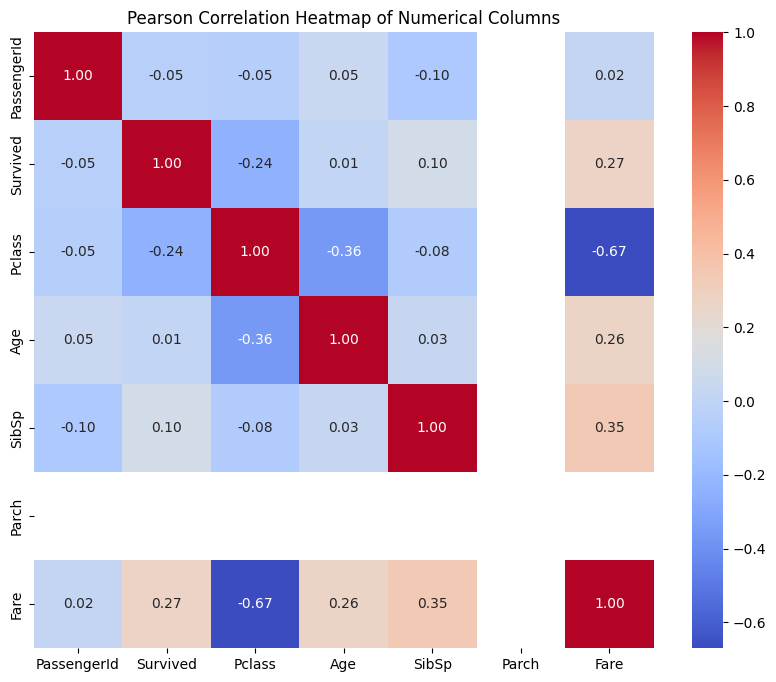

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 7-A  Pearson correlation — numeric columns only
# Select only numerical columns from the DataFrame
numeric_df = inspector.df.select_dtypes(include=[np.number])

# Calculate the Pearson correlation matrix
correlation_matrix = numeric_df.corr(method='pearson')

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Heatmap of Numerical Columns')
plt.show()

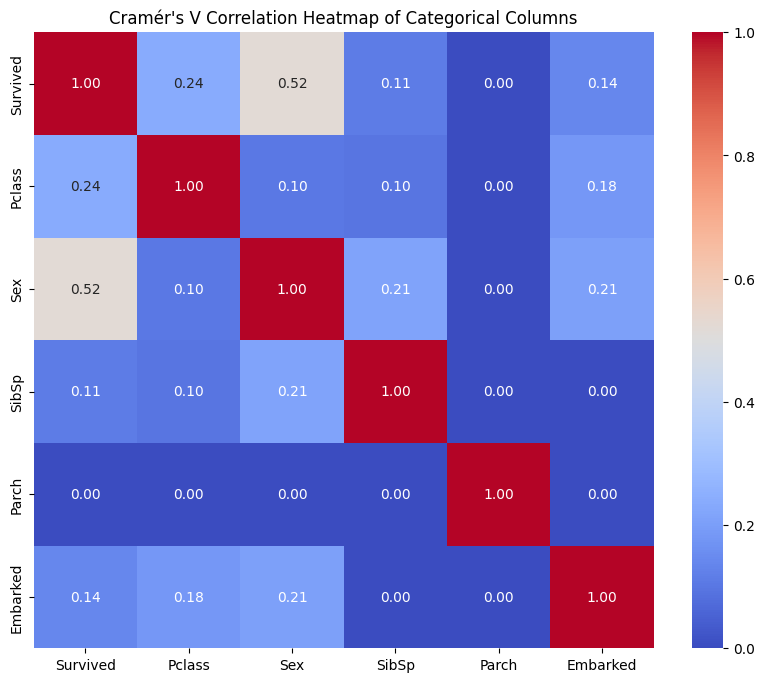

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np

# 7-B Cramér's V — categorical columns only

# Function to calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    n = confusion_matrix.sum().sum()

    # If less than 2 observations, Cramér's V is not meaningful (n-1 would be 0)
    if n < 2:
        return 0.0

    # chi2_contingency can raise ValueError if table is too sparse (e.g., all zeros or very few non-zero cells)
    try:
        chi2 = chi2_contingency(confusion_matrix)[0]
    except ValueError:
        return 0.0 # No meaningful association if chi2 cannot be calculated

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Denominators (n-1) are guaranteed to be > 0 since n >= 2
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)

    # Check the final denominator BEFORE performing the division to prevent RuntimeWarning
    min_corr_den = min((kcorr - 1), (rcorr - 1))

    if min_corr_den <= 0: # If the denominator is zero or negative, return 0.0
        return 0.0
    else:
        return np.sqrt(phi2corr / min_corr_den)

# Select categorical columns (including 'Survived' if it's treated as categorical here)
# We'll consider columns with object dtype or numeric columns with very few unique values as categorical
categorical_cols = []
for col in inspector.df.columns:
    # A column is categorical if its dtype is object or if it's numeric with less than 10 unique values
    if pd.api.types.is_object_dtype(inspector.df[col]) or (pd.api.types.is_numeric_dtype(inspector.df[col]) and inspector.df[col].nunique() < 10):
        categorical_cols.append(col)

# Exclude 'PassengerId' if it's still present and treated as numeric but is effectively an ID
if 'PassengerId' in categorical_cols:
    categorical_cols.remove('PassengerId')

# Filter for columns that actually exist in the DataFrame after any previous operations
categorical_cols = [col for col in categorical_cols if col in inspector.df.columns]

categorical_df = inspector.df[categorical_cols]

# Calculate Cramér's V matrix
v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1.0
        else:
            # Drop NaNs for the two columns being compared to ensure accurate calculation
            temp_df = categorical_df[[col1, col2]].dropna()

            # Ensure there are enough unique values for a meaningful calculation BEFORE calling cramers_v
            if temp_df.empty or temp_df[col1].nunique() < 2 or temp_df[col2].nunique() < 2:
                v_matrix.loc[col1, col2] = 0.0 # No meaningful association or no variability
            else:
                try:
                    v_matrix.loc[col1, col2] = cramers_v(temp_df[col1], temp_df[col2])
                except Exception as e: # Catch any other potential errors during calculation
                    print(f"Error calculating Cramér's V for {col1} and {col2}: {e}")
                    v_matrix.loc[col1, col2] = np.nan # Mark as NaN if an error occurs

v_matrix = v_matrix.astype(float)

# Plot the Cramér's V matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(v_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Cramér\'s V Correlation Heatmap of Categorical Columns')
plt.show()

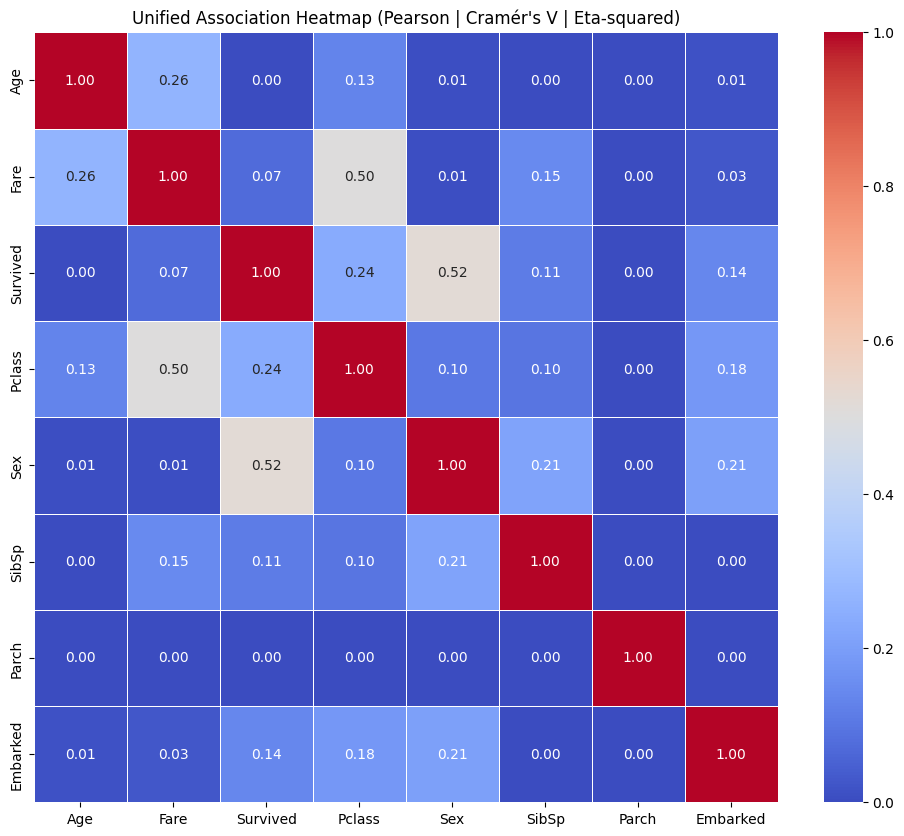

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 7-C  Unified heatmap: Pearson | Cramér's V | Point-Biserial / Eta²

# Function to calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    n = confusion_matrix.sum().sum()
    if n < 2:
        return 0.0

    try:
        chi2 = chi2_contingency(confusion_matrix)[0]
    except ValueError:
        return 0.0

    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    min_corr_den = min((kcorr - 1), (rcorr - 1))
    if min_corr_den <= 0:
        return 0.0
    return np.sqrt(phi2corr / min_corr_den)

# Function to calculate Eta-squared (for Cat-Num association)
def calculate_eta_squared(categorical_series, numerical_series):
    combined_df = pd.DataFrame({'category': categorical_series, 'value': numerical_series}).dropna()
    if combined_df.empty:
        return 0.0

    categories = combined_df['category'].unique()
    if len(categories) < 2:
        return 0.0

    data_groups = [combined_df['value'][combined_df['category'] == cat] for cat in categories if not combined_df['value'][combined_df['category'] == cat].empty]
    valid_groups = [group for group in data_groups if group.count() > 0]
    if len(valid_groups) < 2:
        return 0.0

    ss_total = ((combined_df['value'] - combined_df['value'].mean())**2).sum()
    if ss_total == 0:
        return 0.0

    ss_within = sum(((group - group.mean())**2).sum() for group in valid_groups)
    ss_between = ss_total - ss_within
    eta_sq = ss_between / ss_total
    return eta_sq

# --- Determine column types ---
numeric_cols = []
categorical_cols = []

for col in inspector.df.columns:
    if col == 'PassengerId': # Explicitly exclude PassengerId as it's an identifier
        continue
    if pd.api.types.is_numeric_dtype(inspector.df[col]):
        # Treat numeric columns with few unique values as categorical for association purposes
        if inspector.df[col].nunique() < 10:
            categorical_cols.append(col)
        else:
            numeric_cols.append(col)
    elif pd.api.types.is_object_dtype(inspector.df[col]):
        categorical_cols.append(col)

all_cols = numeric_cols + categorical_cols
association_matrix = pd.DataFrame(1.0, index=all_cols, columns=all_cols)

# Calculate associations
for i in all_cols:
    for j in all_cols:
        if i == j:
            continue # Diagonal is already 1.0

        temp_df_cleaned = inspector.df[[i, j]].dropna()

        if temp_df_cleaned.empty:
            association_matrix.loc[i, j] = np.nan
            continue

        series_i = temp_df_cleaned[i]
        series_j = temp_df_cleaned[j]

        # Num-Num (Pearson)
        if i in numeric_cols and j in numeric_cols:
            association = series_i.corr(series_j, method='pearson')
            association_matrix.loc[i, j] = association
        # Cat-Cat (Cramér's V)
        elif i in categorical_cols and j in categorical_cols:
            association = cramers_v(series_i, series_j)
            association_matrix.loc[i, j] = association
        # Num-Cat or Cat-Num (Eta-squared)
        elif (i in numeric_cols and j in categorical_cols) or \
             (i in categorical_cols and j in numeric_cols):
            # Eta-squared takes categorical as the first argument, numerical as the second
            if i in categorical_cols:
                association = calculate_eta_squared(series_i, series_j)
            else:
                association = calculate_eta_squared(series_j, series_i)

            association_matrix.loc[i, j] = association
            association_matrix.loc[j, i] = association # Ensure symmetry

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(association_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Unified Association Heatmap (Pearson | Cramér\'s V | Eta-squared)')
plt.show()

Feature Engineering — Normalisation & Encoding

In [63]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# 8-A  Numeric scaling — three strategies

# Select only numerical columns for scaling, excluding 'PassengerId' and 'Survived' if they are not features to be scaled
numeric_cols_for_scaling = inspector.df.select_dtypes(include=['number']).columns.tolist()
# Exclude 'PassengerId' and 'Survived' if they are identifiers/targets and not features to be scaled
if 'PassengerId' in numeric_cols_for_scaling: numeric_cols_for_scaling.remove('PassengerId')
if 'Survived' in numeric_cols_for_scaling: numeric_cols_for_scaling.remove('Survived')
if 'Pclass' in numeric_cols_for_scaling: numeric_cols_for_scaling.remove('Pclass') # Pclass might be better as categorical or one-hot encoded

df_to_scale = inspector.df[numeric_cols_for_scaling].copy()

# Initialize scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Apply Min-Max Scaling
norm_minmax_scaled = minmax_scaler.fit_transform(df_to_scale)
norm_minmax = pd.DataFrame(norm_minmax_scaled, columns=numeric_cols_for_scaling, index=inspector.df.index)

# Apply Standard Scaling (Z-score)
norm_standard_scaled = standard_scaler.fit_transform(df_to_scale)
norm_standard = pd.DataFrame(norm_standard_scaled, columns=numeric_cols_for_scaling, index=inspector.df.index)

# Apply Robust Scaling (IQR)
norm_robust_scaled = robust_scaler.fit_transform(df_to_scale)
norm_robust = pd.DataFrame(norm_robust_scaled, columns=numeric_cols_for_scaling, index=inspector.df.index)

print('Min-Max sample:')
display(norm_minmax.head())

print('\nStandard (Z-score) sample:')
display(norm_standard.head())

print('\nRobust (IQR) sample:')
display(norm_robust.head())

Min-Max sample:


,Age,SibSp,Parch,Fare
0,0.469388,0.5,0.0,0.118512
2,0.428571,0.0,0.0,0.236276
3,0.612245,0.5,0.0,0.868002
4,0.612245,0.0,0.0,0.131590
5,0.469388,0.0,0.0,0.138264



Standard (Z-score) sample:


,Age,SibSp,Parch,Fare
0,-0.153846,1.800735,0.0,-0.610509
2,-0.388065,-0.448235,0.0,-0.038394
3,0.665922,1.800735,0.0,3.030625
4,0.665922,-0.448235,0.0,-0.546978
5,-0.153846,-0.448235,0.0,-0.514553



Robust (IQR) sample:


,Age,SibSp,Parch,Fare
0,0.000000,1.0,0.0,-0.174923
2,-0.235294,0.0,0.0,0.717238
3,0.823529,1.0,0.0,5.503096
4,0.823529,0.0,0.0,-0.075851
5,0.000000,0.0,0.0,-0.025288


In [65]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler

# 8-B  Categorical encoding — three strategies

# Identify categorical columns for encoding
# We'll include 'Sex', 'Embarked' (object dtypes) and 'Pclass' (int, but represents categories)
categorical_cols_to_encode = ['Sex', 'Embarked', 'Pclass']

# Ensure columns exist in the current inspector.df
categorical_cols_to_encode = [col for col in categorical_cols_to_encode if col in inspector.df.columns]

# --- One-Hot Encoding ---
# Create a copy for one-hot encoding to avoid modifying the original DataFrame directly
df_onehot_base = inspector.df[categorical_cols_to_encode].copy()

# Initialize OneHotEncoder
# sparse_output=False ensures a dense array output, easier to convert to DataFrame
# handle_unknown='ignore' will output zeros for unknown categories encountered during transform
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the selected categorical columns
encoded_data_onehot = onehot_encoder.fit_transform(df_onehot_base)

# Get feature names for the new one-hot encoded columns
onehot_feature_names = onehot_encoder.get_feature_names_out(categorical_cols_to_encode)

# Convert the encoded array back to a DataFrame
enc_onehot = pd.DataFrame(encoded_data_onehot, columns=onehot_feature_names, index=inspector.df.index)


# --- Ordinal Encoding ---
# Create a copy for ordinal encoding
df_ordinal_base = inspector.df[categorical_cols_to_encode].copy()

# Initialize OrdinalEncoder
# handle_unknown='use_encoded_value' and unknown_value=-1 handles unseen categories
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit and transform the selected categorical columns
encoded_data_ordinal = ordinal_encoder.fit_transform(df_ordinal_base)

# Convert the encoded array back to a DataFrame
enc_ordinal = pd.DataFrame(encoded_data_ordinal, columns=categorical_cols_to_encode, index=inspector.df.index)


# --- Uniform (0–1 scaled from Ordinal) Encoding ---
# For 'uniform' encoding of categorical data, we can interpret this as scaling the
# ordinal encoded values to a 0-1 range using Min-Max Scaling.
# We will use the results from the ordinal encoding as input.
df_uniform_base = enc_ordinal.copy()

# Initialize MinMaxScaler
minmax_scaler_uniform = MinMaxScaler()

# Apply Min-Max scaling to the ordinal encoded data
uniform_scaled_data = minmax_scaler_uniform.fit_transform(df_uniform_base)

# Convert the scaled array back to a DataFrame
enc_uniform = pd.DataFrame(uniform_scaled_data, columns=categorical_cols_to_encode, index=inspector.df.index)


print('One-Hot sample:')
display(enc_onehot.head())

print('\nOrdinal sample:')
display(enc_ordinal.head())

print('\nUniform (0–1 scaled from Ordinal) sample:')
display(enc_uniform.head())

One-Hot sample:


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
5,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0



Ordinal sample:


,Sex,Embarked,Pclass
0,1.0,2.0,2.0
2,0.0,2.0,2.0
3,0.0,2.0,0.0
4,1.0,2.0,2.0
5,1.0,1.0,2.0



Uniform (0–1 scaled from Ordinal) sample:


,Sex,Embarked,Pclass
0,1.0,1.0,1.0
2,0.0,1.0,1.0
3,0.0,1.0,0.0
4,1.0,1.0,1.0
5,1.0,0.5,1.0


In [67]:
import pandas as pd

# 8-C  Merged ML-ready DataFrame (robust numeric + ordinal categorical)

# Combine the robustly scaled numerical data with the ordinal encoded categorical data
# We ensure the indices align for correct merging
final_df = pd.concat([norm_robust, enc_ordinal], axis=1)

display(final_df.head())
print('Shape:', final_df.shape)

,Age,SibSp,Parch,Fare,Sex,Embarked,Pclass
0,0.000000,1.0,0.0,-0.174923,1.0,2.0,2.0
2,-0.235294,0.0,0.0,0.717238,0.0,2.0,2.0
3,0.823529,1.0,0.0,5.503096,0.0,2.0,0.0
4,0.823529,0.0,0.0,-0.075851,1.0,2.0,2.0
5,0.000000,0.0,0.0,-0.025288,1.0,1.0,2.0


Shape: (577, 7)


Custom PlottingMethods

In [68]:
# Instantiate the standalone plotter
PLT = PlottingMethods()

In [70]:
# 9-A  List all available chart methods

# Get all callable attributes (methods) of the PLT object that don't start with '_'
public_methods = [method_name for method_name in dir(PLT) if callable(getattr(PLT, method_name)) and not method_name.startswith('_')]

# Display them as a DataFrame for readability
response_df = pd.DataFrame(public_methods, columns=['Available Plotting Methods'])
display(response_df)

,Available Plotting Methods
0,generate_bar_chart
1,generate_histogram
2,generate_pie_chart


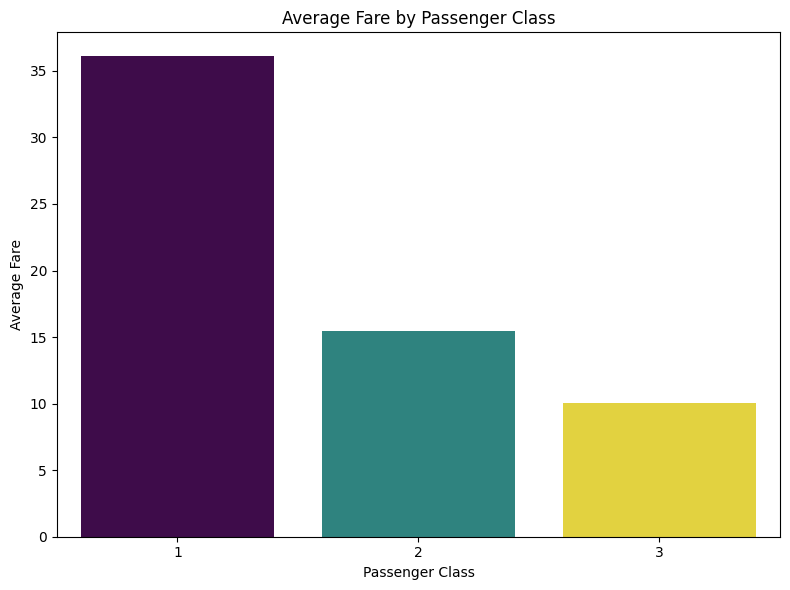

In [74]:
# 9-B  Bar chart: average Fare per Passenger Class
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average fare per passenger class
avg_fare_per_class = inspector.df.groupby('Pclass')['Fare'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='Pclass', y='Fare', data=avg_fare_per_class, palette='viridis', hue='Pclass', legend=False)
plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

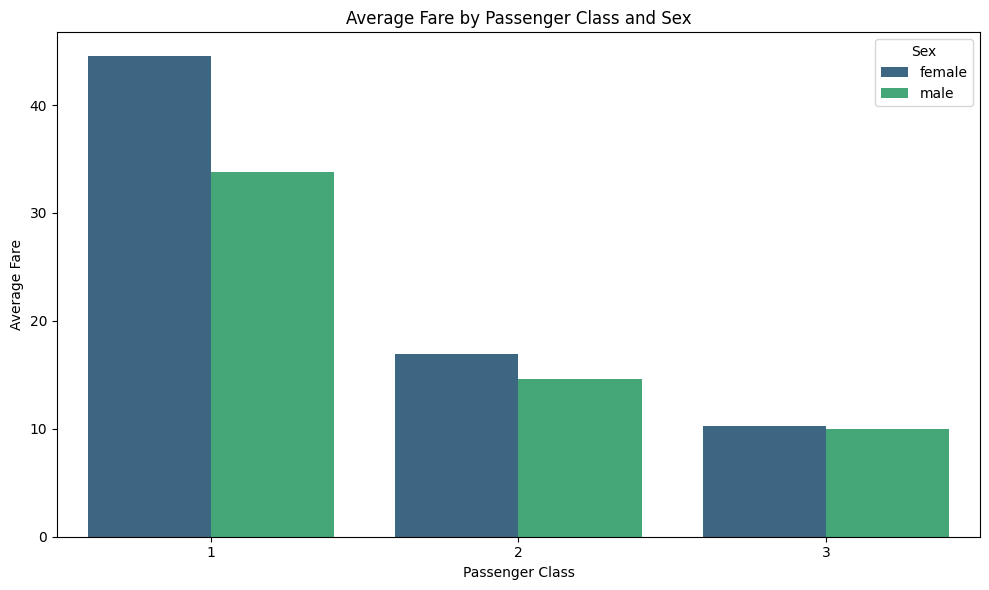

In [76]:
# 9-C  Grouped bar chart: Fare by Pclass, coloured by Sex
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average fare per passenger class and sex
avg_fare_by_class_sex = inspector.df.groupby(['Pclass', 'Sex'])['Fare'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Fare', hue='Sex', data=avg_fare_by_class_sex, palette='viridis')
plt.title('Average Fare by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

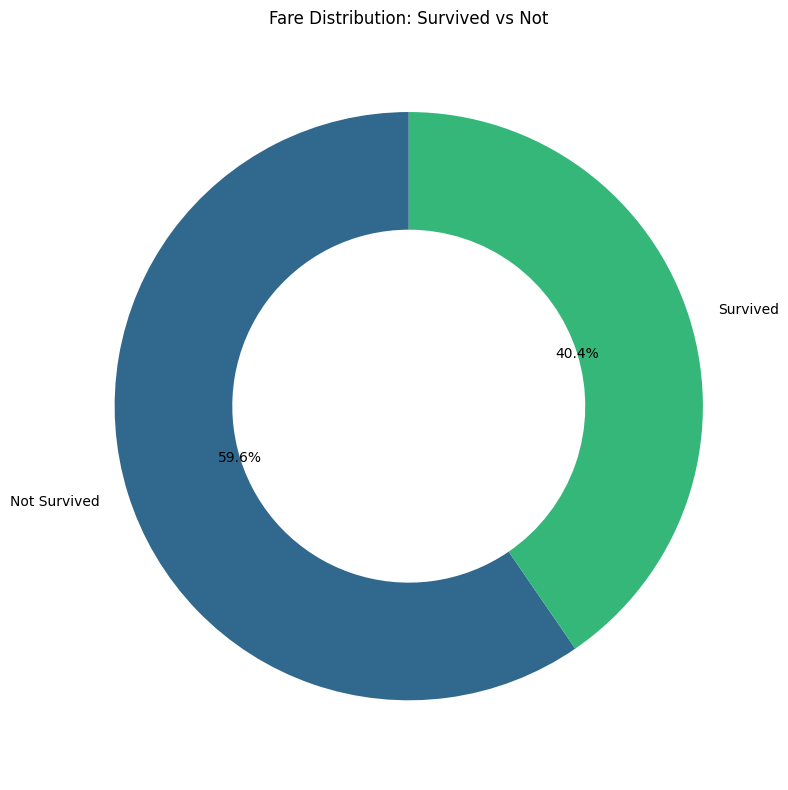

In [78]:
# 9-D  Pie chart: survival split (donut style)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the sum of Fare for each 'Survived' category
survival_fare_distribution = inspector.df.groupby('Survived')['Fare'].sum()

# Create a pie chart (donut style)
plt.figure(figsize=(8, 8))

# Wedge properties
wedges, texts, autotexts = plt.pie(survival_fare_distribution,
                                   labels=['Not Survived', 'Survived'], # Custom labels
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=sns.color_palette('viridis', 2),
                                   wedgeprops=dict(width=0.4)) # Creates the donut hole

# Draw a circle in the center to make it a donut chart
centre_circle = plt.Circle((0,0),0.25,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Fare Distribution: Survived vs Not')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

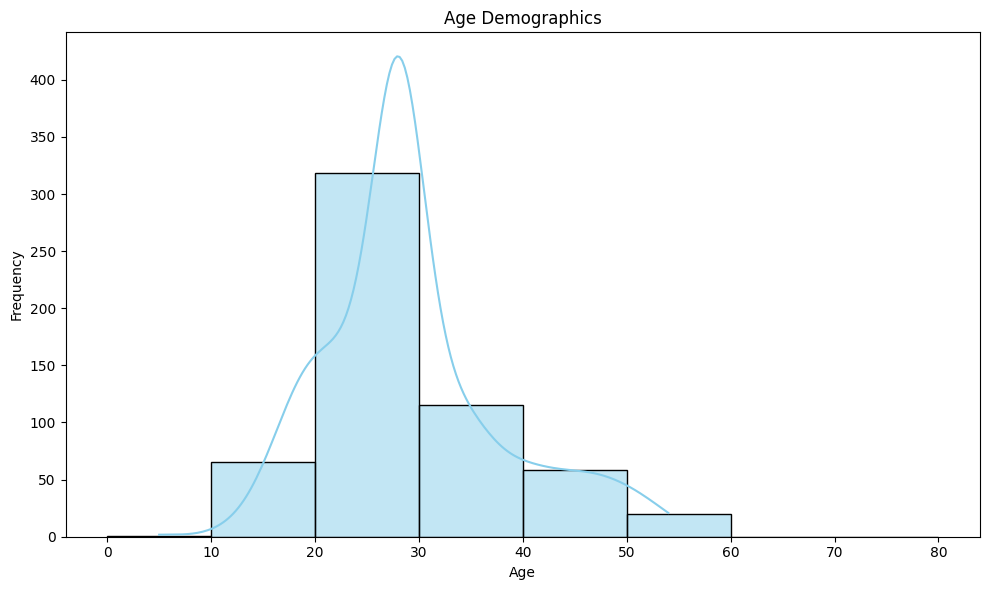

In [80]:
# 9-E  Histogram: Age distribution with custom bins
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom bins
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

plt.figure(figsize=(10, 6))
sns.histplot(inspector.df['Age'], bins=bins, kde=True, color='skyblue', edgecolor='black')
plt.title('Age Demographics')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.xticks(bins) # Set x-ticks to correspond to the bin edges
plt.tight_layout()
plt.show()

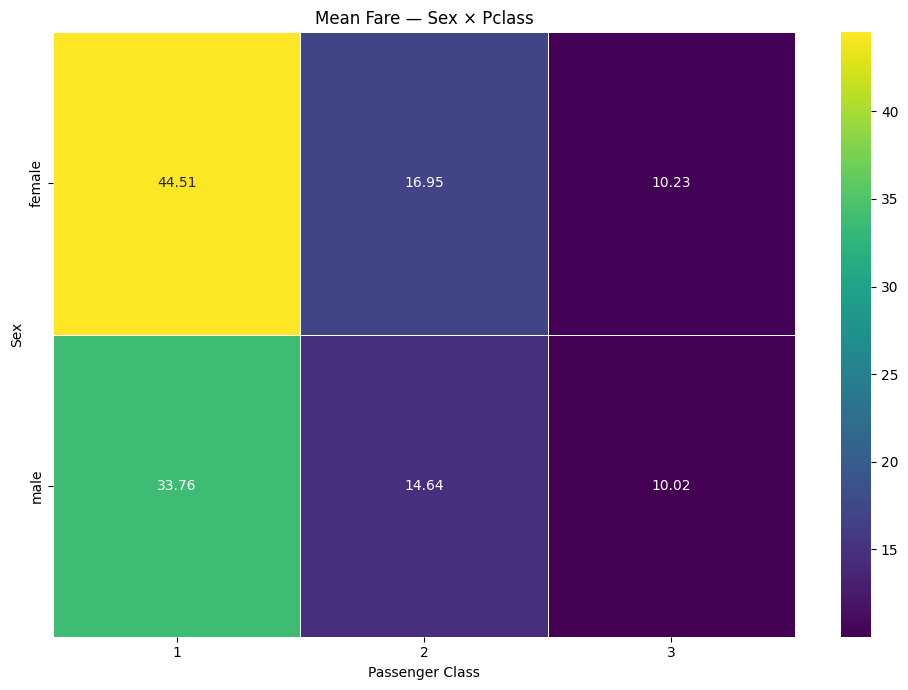

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 9-F  Pivot heatmap: mean Fare by Sex × Pclass

# Create a pivot table for mean Fare by Sex and Pclass
pivot_table = inspector.df.pivot_table(values='Fare',
                                      index='Sex',
                                      columns='Pclass',
                                      aggfunc='mean')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Mean Fare — Sex × Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Sex')
plt.tight_layout()
plt.show()

In [84]:
import plotly.graph_objects as go
import pandas as pd

# 9-G  Sankey diagram: Embarked → Pclass flow (weighted by Fare)

# Prepare data for Sankey diagram
# Aggregate 'Fare' for each unique combination of 'Embarked' and 'Pclass'
sankey_data = inspector.df.groupby(['Embarked', 'Pclass'])['Fare'].sum().reset_index()

# Map unique categories to numerical indices for plotly
# All unique sources and targets become nodes
all_nodes = pd.concat([sankey_data['Embarked'], sankey_data['Pclass']]).unique()
node_mapping = {node: i for i, node in enumerate(all_nodes)}

# Create source, target, and value lists for Plotly Sankey
source = [node_mapping[s] for s in sankey_data['Embarked']]
target = [node_mapping[t] for t in sankey_data['Pclass']]
value = sankey_data['Fare']

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=[str(node) for node in all_nodes] # Labels for nodes
    ),
    link=dict(
        source=source, # indices correspond to labels, ordered as follows: source, then target
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="Sankey Diagram: Embarked \u2192 Pclass Flow (Weighted by Fare)", font_size=10)
fig.show()

In [86]:
import plotly.express as px

# 9-H  Sunburst chart: Sex → Pclass hierarchy, sized by Fare

fig = px.sunburst(inspector.df,
                    path=['Sex', 'Pclass'],
                    values='Fare',
                    title='Fare Hierarchy: Sex → Passenger Class')
fig.show()